# General setup

In [1]:
# Imports
import argparse
import re
import json
import warnings
import numpy as np
from modules.CHILI import CHILI
from modules.net import SCVAE
from torch_geometric.loader import DataLoader
import torch
from torch.utils.data import TensorDataset
import datetime
import pathlib
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from ase import Atoms
from ase.io import write
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from modules.loss_functions import weighted_MSELoss, weighted_CrossEntropyLoss
from copy import deepcopy

warnings.filterwarnings("ignore")

In [2]:
# Functions
def create_cif(cell_params, cell_positions, cell_atoms, filename, prediction=True, composition=None, simplified_atom_identities=False):
    """
    Create a CIF file from the cell parameters, positions and atoms
    """
    if prediction:
        # Find argmax of atoms
        cell_atoms = np.argmax(cell_atoms, axis=1)

    # Remove atoms with atom number 0
    cell_positions = cell_positions[cell_atoms != 0]
    cell_atoms = cell_atoms[cell_atoms != 0]
    
    # Remove atoms not in the unit cell
    cell_atoms = cell_atoms[(cell_positions[:,0] < 0.95) & (cell_positions[:,1] < 0.95) & (cell_positions[:,2] < 0.95)]
    cell_positions = cell_positions[(cell_positions[:,0] < 0.95) & (cell_positions[:,1] < 0.95) & (cell_positions[:,2] < 0.95)]
    
    
    if simplified_atom_identities:
        cell_atoms = np.where(cell_atoms == 1, 8, cell_atoms)
        cell_atoms = np.where(cell_atoms == 2, 26, cell_atoms)
    
    # Create Atoms object
    atoms = Atoms(cell_atoms, scaled_positions=cell_positions, cell=cell_params)

    if not composition:
        composition = str(atoms.symbols)

    # Write CIF
    write(filename + f'.cif', images=atoms, format='cif') # _{composition}

    if not prediction:
        return composition
    return None

In [3]:
# Setup
setup_json_path = './models/Combined_data_harsher_normalization/setup_json.json'
with open(setup_json_path, 'r') as setup_json_file:
    setup_json = json.load(setup_json_file)

# Make prediction folders
experimental_folder = f'{setup_json["model_root"]}{setup_json["experiment_name"]}/experimental_predictions'
pathlib.Path(experimental_folder).mkdir(parents=True, exist_ok=True)

interpolation_folder = f'{setup_json["model_root"]}{setup_json["experiment_name"]}/interpolation_predictions'
pathlib.Path(interpolation_folder).mkdir(parents=True, exist_ok=True)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
# Load model
model = SCVAE(
    latent_dim=setup_json['model']['latent_dim'],
    out_dim=setup_json['model']['out_dim'],
    prior_factor=setup_json['model']['prior_factor'],
    gnn_dim=setup_json['model']['gnn_dim'],
    gnn_heads=setup_json['model']['gnn_heads'],
    gnn_edge_dim=setup_json['model']['gnn_edge_dim'],
    scattering_channels=setup_json['model']['scattering_channels'],
    scattering_dim=setup_json['model']['scattering_dim'],
    scattering_kernel_size=setup_json['model']['scattering_kernel_size'],
    scattering_stride=setup_json['model']['scattering_stride'],
    scattering_padding=setup_json['model']['scattering_padding'],
    composition_dim=setup_json['model']['composition_dim'],
    decoder_hidden_dim=setup_json['model']['decoder_hidden_dim'],
    position_output_dim=setup_json['model']['position_output_dim'],
    atom_output_dim=setup_json['model']['atom_output_dim'],
    cell_output_dim=setup_json['model']['cell_output_dim'],
).to(device)

# Load model weights
model.load_state_dict(torch.load(setup_json['start_from_checkpoint']))
    


<All keys matched successfully>

In [5]:
# Load normalization parameters
if setup_json['data']['normalize_cell_parameters']:
    cell_means = torch.tensor([
        setup_json['data']['cell_normalization']['a']['mean'],
        setup_json['data']['cell_normalization']['b']['mean'],
        setup_json['data']['cell_normalization']['c']['mean'],
        setup_json['data']['cell_normalization']['alpha']['mean'],
        setup_json['data']['cell_normalization']['beta']['mean'],
        setup_json['data']['cell_normalization']['gamma']['mean'],
    ]).float().to(device)
    cell_stds = torch.tensor([
        setup_json['data']['cell_normalization']['a']['std'],
        setup_json['data']['cell_normalization']['b']['std'],
        setup_json['data']['cell_normalization']['c']['std'],
        setup_json['data']['cell_normalization']['alpha']['std'],
        setup_json['data']['cell_normalization']['beta']['std'],
        setup_json['data']['cell_normalization']['gamma']['std'],
    ]).float().to(device)

if setup_json['data']['normalize_atom_positions']:
    atom_position_means = torch.tensor(setup_json['data']['atom_position_normalization']['mean']).float().to(device)
    atom_position_stds = torch.tensor(setup_json['data']['atom_position_normalization']['std']).float().to(device)

if setup_json['data']['normalize_distances']:
    distance_means = torch.tensor(setup_json['data']['distance_normalization']['mean']).float().to(device)
    distance_stds = torch.tensor(setup_json['data']['distance_normalization']['std']).float().to(device)

beta = setup_json['training']['beta']
out_dim = setup_json['model']['out_dim']

# Load model test results

In [6]:
# Load results from test script
with open(f'{setup_json["model_root"]}{setup_json["experiment_name"]}/CrystalTypeAnalysis/losses.json', 'r') as f:
    losses_json = json.load(f)
df_losses = pd.DataFrame(losses_json)

with open(f'{setup_json["model_root"]}{setup_json["experiment_name"]}/CrystalTypeAnalysis/reconstructions.json', 'r') as f:
    rec_json = json.load(f)
df_rec = pd.DataFrame(rec_json)
df_rec[['ls1', 'ls2']] = df_rec['latent_space_mean'].apply(pd.Series)

In [7]:
df_losses.head()

,total,reconstruction_loss,cell_parameters,cell_positions,cell_atoms,kld,crystalType,particleSize
0,-4.706727,0.001644,0.000712,0.000737,0.000195,0.014011,RheniumTrioxide,11.694150
1,-0.954289,0.004097,0.000572,0.003420,0.000105,0.712833,Wurtzite,23.968201
2,1.606931,4.791619,0.438971,0.966713,3.385935,0.313921,CaesiumChloride,14.847806
3,-5.916173,0.001871,0.001001,0.000640,0.000230,0.001589,RheniumTrioxide,53.604038
4,-3.917453,0.003318,0.001606,0.000607,0.001105,0.031135,RheniumTrioxide,11.700600


In [8]:
df_rec.head()

,crystalType,n_atoms,n_oxygens,n_metals,cell_parameters,cell_positions,cell_atoms,latent_space_mean,latent_space_std,ls1,ls2
0,RheniumTrioxide,56,36,20,"[3.870595693588257, 3.848803758621216, 3.87144...","[[0.008999999612569809, 0.0020099999383091927,...","[2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, ...","[-0.11839155852794647, 0.9956525564193726]","[0.06994210928678513, 0.09491664916276932]",-0.118392,0.995653
1,Wurtzite,56,25,31,"[3.638019323348999, 3.663578987121582, 5.85040...","[[0.38005000352859497, 0.7135400176048279, -0....","[2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 1, 1, 2, 2, ...","[0.9041052460670471, 0.06978431344032288]","[0.07835176587104797, 0.059981752187013626]",0.904105,0.069784
2,CaesiumChloride,56,26,30,"[5.201122283935547, 5.1036176681518555, 5.2600...","[[0.03477000072598457, -0.04836000129580498, 0...","[1, 2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 1, ...","[-0.8994700312614441, 0.7804950475692749]","[0.08227548003196716, 0.10670840740203857]",-0.899470,0.780495
3,RheniumTrioxide,56,36,20,"[3.8640661239624023, 3.8507070541381836, 3.849...","[[0.0022299999836832285, -0.003299999982118606...","[2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, ...","[-0.06708452105522156, 0.8979175686836243]","[0.06837381422519684, 0.08569661527872086]",-0.067085,0.897918
4,RheniumTrioxide,56,36,20,"[3.878068685531616, 3.85567307472229, 3.973027...","[[0.03263000026345253, 0.009499999694526196, 0...","[2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, ...","[-0.0853823870420456, 0.901531457901001]","[0.06980704516172409, 0.09161238372325897]",-0.085382,0.901531


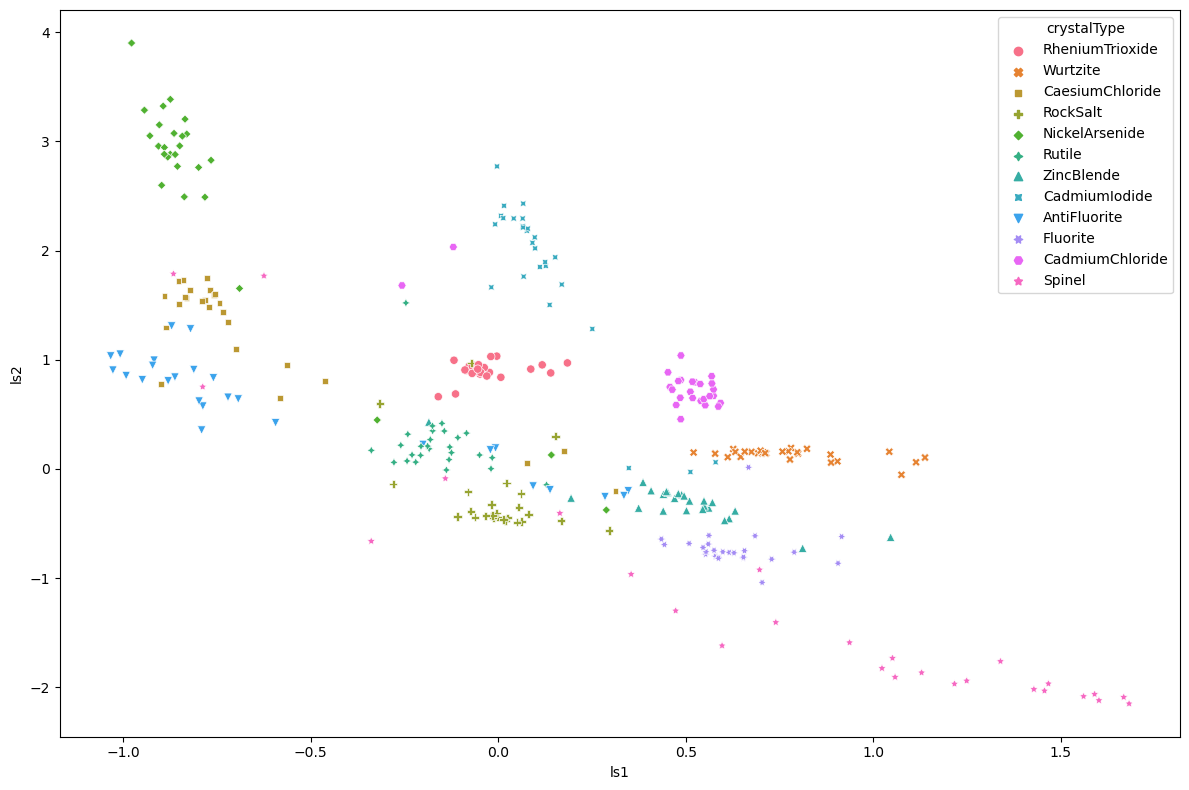

In [9]:
# Plot latent space
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_rec, x='ls1', y='ls2', hue='crystalType', style='crystalType')
plt.tight_layout()
plt.show()

# Experimental data

In [10]:
data_folder = './data/Experimental/Jens/'

# Load experimental data
data_paths = [str(p) for p in pathlib.Path(data_folder).glob('*.gr')]

data_filepath = []
data_composition_string = []
data_composition = []
data_pdf = []
for data_path in data_paths:
    with open(data_path, 'r') as f:
        # Load data
        line_counter = 0
        for line in f:
            if line.startswith('composition'):
                composition = line.split(' ')[-1]
            if line.startswith('0'):
                header_line = line_counter
                break
            line_counter += 1
    
    # Save composition string
    composition_string = deepcopy(composition)

    # Remove stochiometry from composition
    composition = re.sub(r'[0-9\.]+', '', composition)

    # Remove line breaks
    composition = composition.replace('\n', '')

    # # Split string on capital letters
    composition = re.findall('[A-Z][^A-Z]*', composition)

    # Translate composition to atom numbers
    composition = Atoms(symbols=composition).get_atomic_numbers()
    
    composition_onehot = np.zeros(119)
    composition_onehot[composition] = 1
    
    
    # Load data
    data = pd.read_csv(data_path, sep=' ', skiprows=header_line, names=['r [Å]', 'G(r) [Å⁻²]'])
    
    data_r = np.arange(0,60,0.01)
    data_Gr = np.interp(data_r, data['r [Å]'], data['G(r) [Å⁻²]'], left=0, right=0)
    data_Gr = data_Gr / np.amax(data_Gr)
    
    data_filepath.append(data_path)
    data_composition_string.append(composition_string)
    data_composition.append(composition_onehot)
    data_pdf.append(data_Gr)

# Convert to tensors
data_composition = torch.tensor(data_composition, dtype=torch.long)
data_pdf = torch.tensor(data_pdf, dtype=torch.float32)
data_composition_string_index = torch.tensor(np.arange(len(data_composition_string)))
data_filepath_index = torch.tensor(np.arange(len(data_filepath)))

exp_data = TensorDataset(data_pdf, data_composition, data_composition_string_index, data_filepath_index)

# Dataloader
exp_loader = DataLoader(exp_data, batch_size=10, shuffle=False)

# Results dict
exp_results = {
    'composition': [],
    'pdf': [],
    'prior_mean': [],
    'prior_log_std': [],
    'z_sample': [],
    'cell_parameters': [],
    'cell_positions': [],
    'cell_atoms': [],
}

In [11]:
# Inference
model.eval()
for batch in tqdm(exp_loader, desc='Inference', disable=setup_json['disable_tqdm']):
    this_batch_size = len(batch[0])
    pdf, composition, composition_string_index, filepath_index = batch
    pdf = pdf.unsqueeze(-1).to(device)
    composition = composition.float().to(device)
    
    with torch.no_grad():
        cell_parameters, cell_positions, cell_atoms, prior_mean, prior_log_std, z_sample = model.predict(
            pdf, 
            composition,
        )
    
    # Denormalize cell parameters
    if setup_json['data']['normalize_cell_parameters']:
        cell_parameters = (cell_parameters * cell_stds) + cell_means
    
    # Rounding positions to 5 decimals
    cell_positions = torch.round(cell_positions, decimals=5)
    
    # Store composition
    for index in composition_string_index:
        exp_results['composition'].append(data_composition_string[index])
    
    # Store PDF
    exp_results['pdf'].extend(pdf.cpu().tolist())
    
    # Store latent representation
    exp_results['prior_mean'].extend(prior_mean.cpu().tolist())
    exp_results['prior_log_std'].extend(prior_log_std.cpu().tolist())
    exp_results['z_sample'].extend(z_sample.cpu().tolist())
    
    # Store predictions
    exp_results['cell_parameters'].extend(cell_parameters.cpu().tolist())
    exp_results['cell_positions'].extend(cell_positions.cpu().tolist())
    exp_results['cell_atoms'].extend(torch.argmax(cell_atoms, dim=2).cpu().tolist())
    
    # Create CIF files
    for batch_index in range(this_batch_size):
        # Prediction
        try:
            create_cif(
                cell_params = cell_parameters[batch_index].detach().cpu().numpy(),
                cell_positions = cell_positions[batch_index].detach().cpu().numpy(),
                cell_atoms = cell_atoms[batch_index].detach().cpu().numpy(),
                filename = f'{setup_json["model_root"]}{setup_json["experiment_name"]}/experimental_predictions/{data_filepath[data_filepath_index[batch_index]].split("/")[-1].split(".")[0]}',
                prediction=True,
                composition=data_composition_string[composition_string_index[batch_index]],
                simplified_atom_identities=setup_json['training']['simplified_atom_identities'],
            )
        except:
            print(f'Failed to create CIF file for prediction of {data_composition_string[composition_string_index[batch_index]]}.')
    
df_exp_results = pd.DataFrame(exp_results)
df_exp_results[['ls1', 'ls2']] = df_exp_results['prior_mean'].apply(pd.Series)
df_exp_results.head()

,composition,pdf,prior_mean,prior_log_std,z_sample,cell_parameters,cell_positions,cell_atoms,ls1,ls2
0,Cr0.66Mn0.66Fe0.66Ni0.5Cu0.5O4\n,"[[0.0], [3.48158209817484e-05], [6.78441429045...","[1.3435165882110596, -2.1811413764953613]","[0.2498050034046173, 0.10377959161996841]","[2.08027720451355, -2.109815835952759]","[8.512242317199707, 8.447031021118164, 8.01246...","[[0.48563000559806824, 0.5025100111961365, 0.5...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",1.343517,-2.181141
1,Co0.33Ni0.33Zn0.33CrMnO4\n,"[[0.0], [2.2900278509041527e-06], [4.542134774...","[1.3505760431289673, -2.2104921340942383]","[0.26509857177734375, 0.11002641916275024]","[1.2351667881011963, -2.0259451866149902]","[8.644964218139648, 8.578397750854492, 8.15430...","[[0.4821600019931793, 0.48778000473976135, 0.5...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",1.350576,-2.210492
2,Co0.33Ni0.33Cu0.33MnFeO4\n,"[[0.0], [2.3368893380393274e-05], [4.552564132...","[1.307485818862915, -2.201219081878662]","[0.24411466717720032, 0.09771966189146042]","[0.9614145755767822, -2.104203224182129]","[8.549978256225586, 8.502399444580078, 8.08994...","[[0.4746899902820587, 0.4887700080871582, 0.55...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",1.307486,-2.201219
3,Co0.33Zn0.33Ni0.33CrMnO4\n,"[[0.0], [0.001129354815930128], [0.00220868061...","[1.0887621641159058, -2.0461080074310303]","[0.24073539674282074, 0.09837694466114044]","[1.6254496574401855, -1.9739022254943848]","[8.690811157226562, 8.613983154296875, 8.18994...","[[0.48361000418663025, 0.48429998755455017, 0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",1.088762,-2.046108
4,CrMnCo0.33Ni0.33Cu0.33O4\n,"[[0.0], [3.737132601600024e-06], [7.2965626713...","[1.328800082206726, -2.197125196456909]","[0.24965597689151764, 0.1033754050731659]","[1.374735951423645, -2.1941540241241455]","[8.563348770141602, 8.490154266357422, 8.07078...","[[0.48903000354766846, 0.48787999153137207, 0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",1.328800,-2.197125


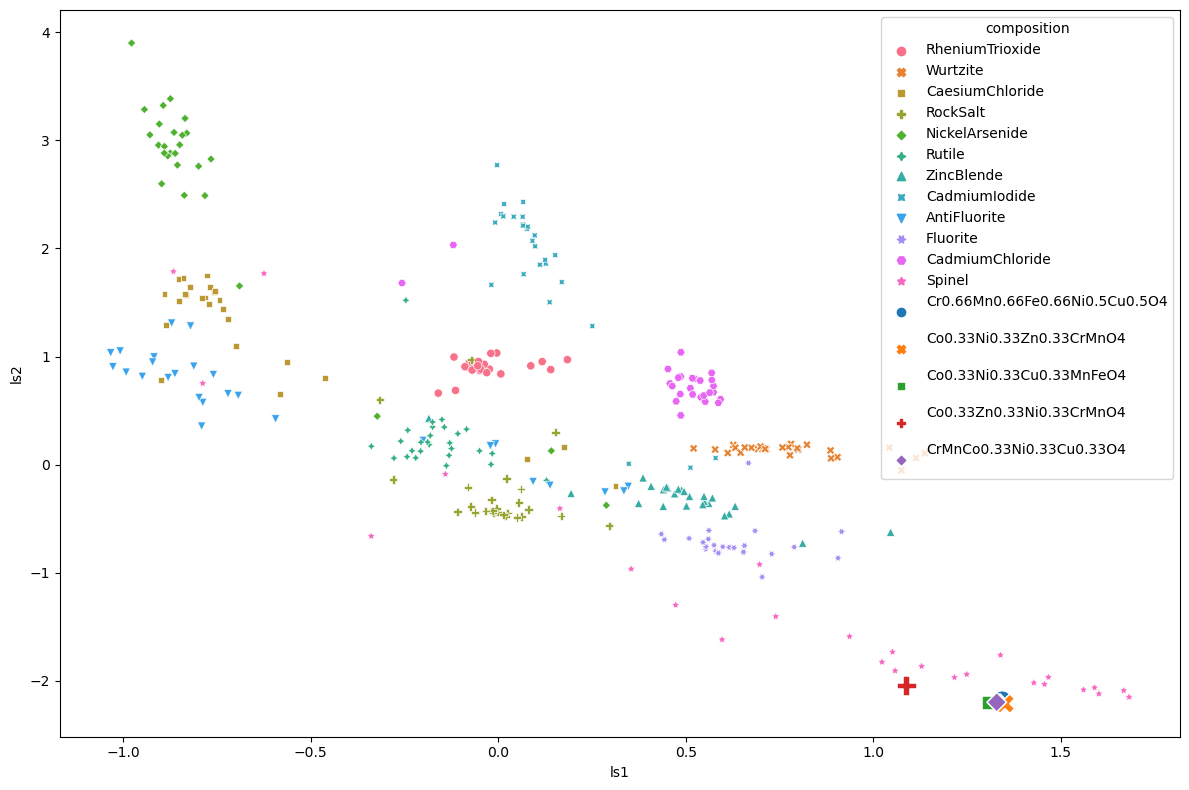

In [12]:
# Plot latent space placement of experimental data
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_rec, x='ls1', y='ls2', hue='crystalType', style='crystalType')
sns.scatterplot(data=df_exp_results, x='ls1', y='ls2', hue='composition', style='composition', s=200)
plt.tight_layout()
plt.show()

# Interpolate in latent space

In [13]:
# Create latent samples for interpolation between two points
n_latent_samples = 10
latent_point_1 = (-0.1,-0.4)
latent_point_2 = (0.55,-0.3)
# Latent samples are n_latent_samples evenly spaced points between the two points
interp_latent = torch.tensor([np.linspace(latent_point_1[i], latent_point_2[i], n_latent_samples) for i in range(len(latent_point_1))]).T.float()
interp_index = torch.tensor([i for i in range(n_latent_samples)])

# Create dataset
interp_dataset = TensorDataset(interp_latent, interp_index)

# Dataloader
interp_loader = DataLoader(interp_dataset, batch_size=10, shuffle=False)

# Results dict
interp_results = {
    'latent_point': [],
    'cell_parameters': [],
    'cell_positions': [],
    'cell_atoms': [],
}

In [14]:
# Inference
model.eval()
for batch in tqdm(interp_loader, desc='Interpolating', disable=setup_json['disable_tqdm']):
    this_batch_size = len(batch[0])
    interp_point, interp_index = batch
    interp_point = interp_point.to(device)
    interp_index = interp_index.to(device)
    composition = None
    
    with torch.no_grad():
        cell_parameters, cell_positions, cell_atoms = model.decode(
            interp_point, 
            composition=composition,
        )
    
    # Denormalize cell parameters
    if setup_json['data']['normalize_cell_parameters']:
        cell_parameters = (cell_parameters * cell_stds) + cell_means
    
    # Rounding positions to 5 decimals
    cell_positions = torch.round(cell_positions, decimals=5)
    
    # Store latent points
    interp_results['latent_point'].extend(interp_point.cpu().tolist())
    
    # Store predictions
    interp_results['cell_parameters'].extend(cell_parameters.cpu().tolist())
    interp_results['cell_positions'].extend(cell_positions.cpu().tolist())
    interp_results['cell_atoms'].extend(torch.argmax(cell_atoms, dim=2).cpu().tolist())
    
    # Create CIF files
    for batch_index in range(this_batch_size):
        # Prediction
        try:
            create_cif(
                cell_params = cell_parameters[batch_index].detach().cpu().numpy(),
                cell_positions = cell_positions[batch_index].detach().cpu().numpy(),
                cell_atoms = cell_atoms[batch_index].detach().cpu().numpy(),
                filename = f'{setup_json["model_root"]}{setup_json["experiment_name"]}/interpolation_predictions/sample{interp_index[batch_index]}',
                prediction=True,
                composition=None,
                simplified_atom_identities=setup_json['training']['simplified_atom_identities'],
            )
        except:
            print(f'Failed to create CIF file for prediction of sample {interp_index[batch_index]}.')
    

In [15]:
df_interp = pd.DataFrame(interp_results)
df_interp[['ls1', 'ls2']] = df_interp['latent_point'].apply(pd.Series)
df_interp.head()

,latent_point,cell_parameters,cell_positions,cell_atoms,ls1,ls2
0,"[-0.10000000149011612, -0.4000000059604645]","[4.633943557739258, 4.664843559265137, 4.59075...","[[-0.003490000031888485, -0.004939999897032976...","[2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, ...",-0.100000,-0.400000
1,"[-0.02777777798473835, -0.3888888955116272]","[4.591976642608643, 4.624886512756348, 4.59212...","[[-0.002240000059828162, 0.0015399999683722854...","[2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, ...",-0.027778,-0.388889
2,"[0.04444444552063942, -0.3777777850627899]","[4.631882667541504, 4.648508071899414, 4.64416...","[[0.0011899999808520079, 0.005249999929219484,...","[2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, ...",0.044444,-0.377778
3,"[0.11666666716337204, -0.36666667461395264]","[4.708687782287598, 4.737643718719482, 4.72325...","[[0.013290000148117542, 0.0006399999838322401,...","[2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, ...",0.116667,-0.366667
4,"[0.18888889253139496, -0.35555556416511536]","[4.797338962554932, 4.858597278594971, 4.81610...","[[0.024150000885128975, 0.005590000189840794, ...","[2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, ...",0.188889,-0.355556


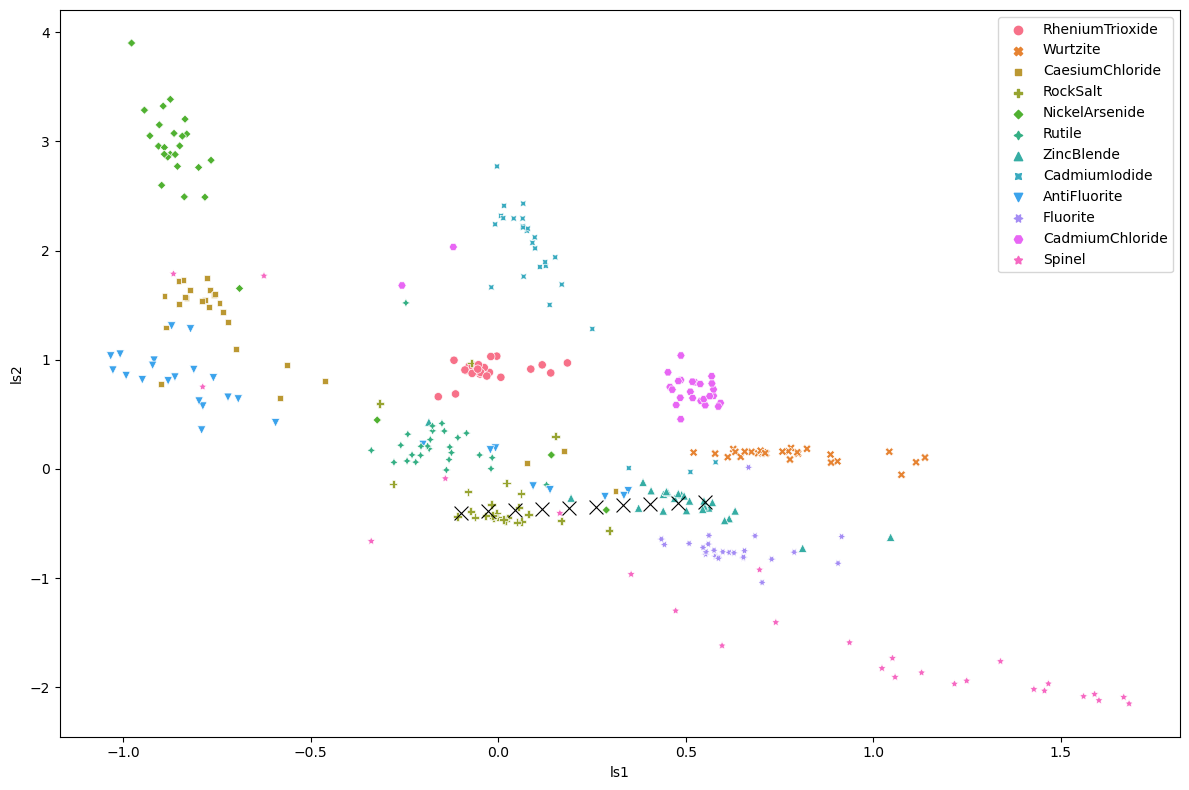

In [16]:

# Plot interpolation results in latent space
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_rec, x='ls1', y='ls2', hue='crystalType', style='crystalType')
sns.scatterplot(data=df_interp, x='ls1', y='ls2', color='black', marker='x', s=100)
plt.tight_layout()
plt.show()